In [195]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from scipy.stats import spearmanr, pearsonr

In [196]:
df = pd.read_csv("insurance_claims_clean.csv", index_col="policy_number")
df.columns

Index(['months_as_customer', 'age', 'policy_bind_date', 'policy_state',
       'policy_csl', 'policy_deductable', 'policy_annual_premium',
       'insured_education_level', 'insured_occupation', 'insured_hobbies',
       'insured_relationship', 'capital_gains', 'capital_loss',
       'incident_date', 'incident_type', 'collision_type', 'incident_severity',
       'authorities_contacted', 'incident_state', 'incident_city',
       'incident_location', 'incident_hour_of_the_day',
       'number_of_vehicles_involved', 'property_damage', 'bodily_injuries',
       'witnesses', 'police_report_available', 'total_claim_amount',
       'injury_claim', 'property_claim', 'vehicle_claim', 'auto_make',
       'auto_model', 'auto_year', 'insured_zip_class', 'policy_bind_year',
       'policy_bind_month', 'policy_bind_weekday', 'incident_month',
       'incident_weekday', 'capital_total', 'fraud', 'gender'],
      dtype='object')

In [197]:
df.nunique().T

months_as_customer              391
age                              46
policy_bind_date                951
policy_state                      3
policy_csl                        3
policy_deductable                 3
policy_annual_premium           991
insured_education_level           7
insured_occupation               14
insured_hobbies                  20
insured_relationship              6
capital_gains                   338
capital_loss                    354
incident_date                    60
incident_type                     4
collision_type                    4
incident_severity                 4
authorities_contacted             4
incident_state                    7
incident_city                     7
incident_location              1000
incident_hour_of_the_day         24
number_of_vehicles_involved       4
property_damage                   3
bodily_injuries                   3
witnesses                         4
police_report_available           3
total_claim_amount          

In [198]:
col_quan = df.select_dtypes(include=['float64', 'int64']).columns
# col_qual = df.drop(col_quan,axis=1).columns
# col_qual = col_qual.drop(["incident_state",'policy_bind_date'])

# Data Viz / Statistical tests on quantitative features

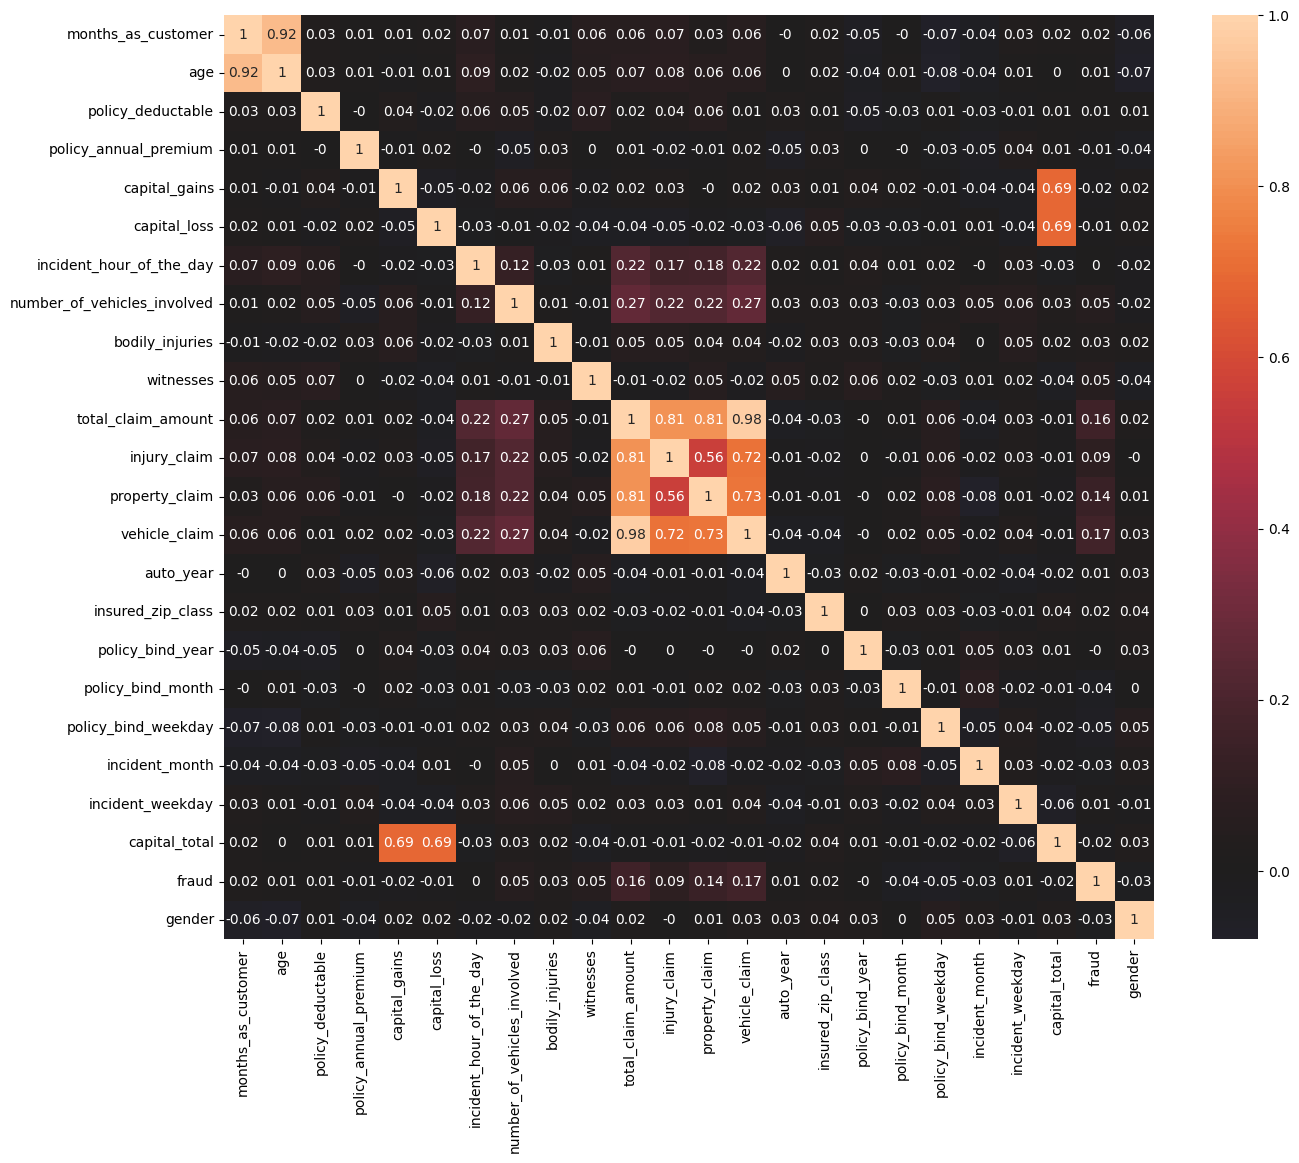

In [199]:
#heatmap to check correlation
plt.figure(figsize = (15,12))
sns.heatmap(np.round(df[col_quan].corr(),2), annot=True, center =0);

Assumption Total claim is sum of all claims is:  True


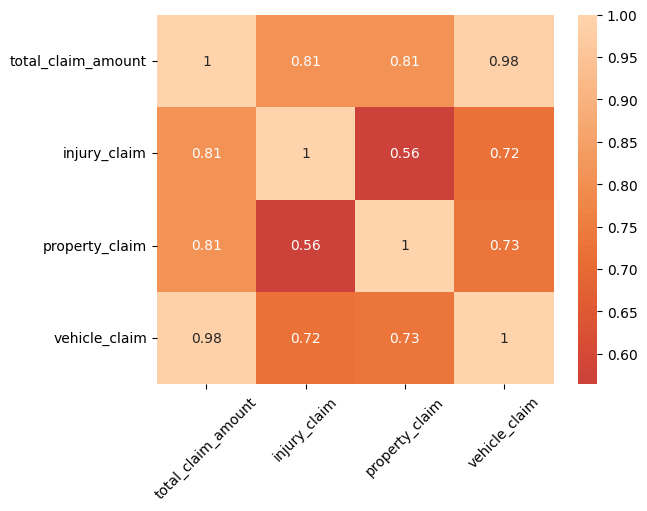

In [200]:
#check features: 'total_claim_amount', "injury_claim", 'property_claim','vehicle_claim'
claim=['total_claim_amount', "injury_claim", 'property_claim','vehicle_claim']
sns.heatmap(np.round(df[claim].corr(),3),annot=True,center=0)
plt.xticks(rotation=45);

print("Assumption Total claim is sum of all claims is: ", (df['total_claim_amount']-(df['injury_claim']+df['vehicle_claim']+df['property_claim'])).sum()==0)

In [201]:

col_quan=col_quan.drop(["total_claim_amount"])


## Statistical tests Pearson / Spearman

In [202]:
#run Pearson Test for linear relation
dic_pearson ={}
dic_spearman ={}

for col in col_quan:
    X=df[col]
    Y=df['fraud']
    dic_pearson[col]=pearsonr(X,Y)[1]
    dic_spearman[col]=spearmanr(X,Y)[1]

df_pearson = pd.DataFrame(list(dic_pearson.items()), columns=['feature', 'pearson_p_value'])
df_spearman = pd.DataFrame(list(dic_spearman.items()), columns=['feature', 'spearman_p_value'])

df_stats=df_pearson.merge(df_spearman, on="feature", how='left')

df_stats['Significant_p'] = df_stats['pearson_p_value'] < 0.05
df_stats['Significant_s'] = df_stats['spearman_p_value'] < 0.05
display(df_stats[df_stats["Significant_p"]])
display(df_stats[df_stats["Significant_s"]])

,feature,pearson_p_value,spearman_p_value,Significant_p,Significant_s
10,injury_claim,3.986262e-03,0.005440,True,True
11,property_claim,1.218941e-05,0.000023,True,True
12,vehicle_claim,6.297261e-08,0.000005,True,True
21,fraud,0.000000e+00,0.000000,True,True


,feature,pearson_p_value,spearman_p_value,Significant_p,Significant_s
10,injury_claim,3.986262e-03,0.005440,True,True
11,property_claim,1.218941e-05,0.000023,True,True
12,vehicle_claim,6.297261e-08,0.000005,True,True
21,fraud,0.000000e+00,0.000000,True,True


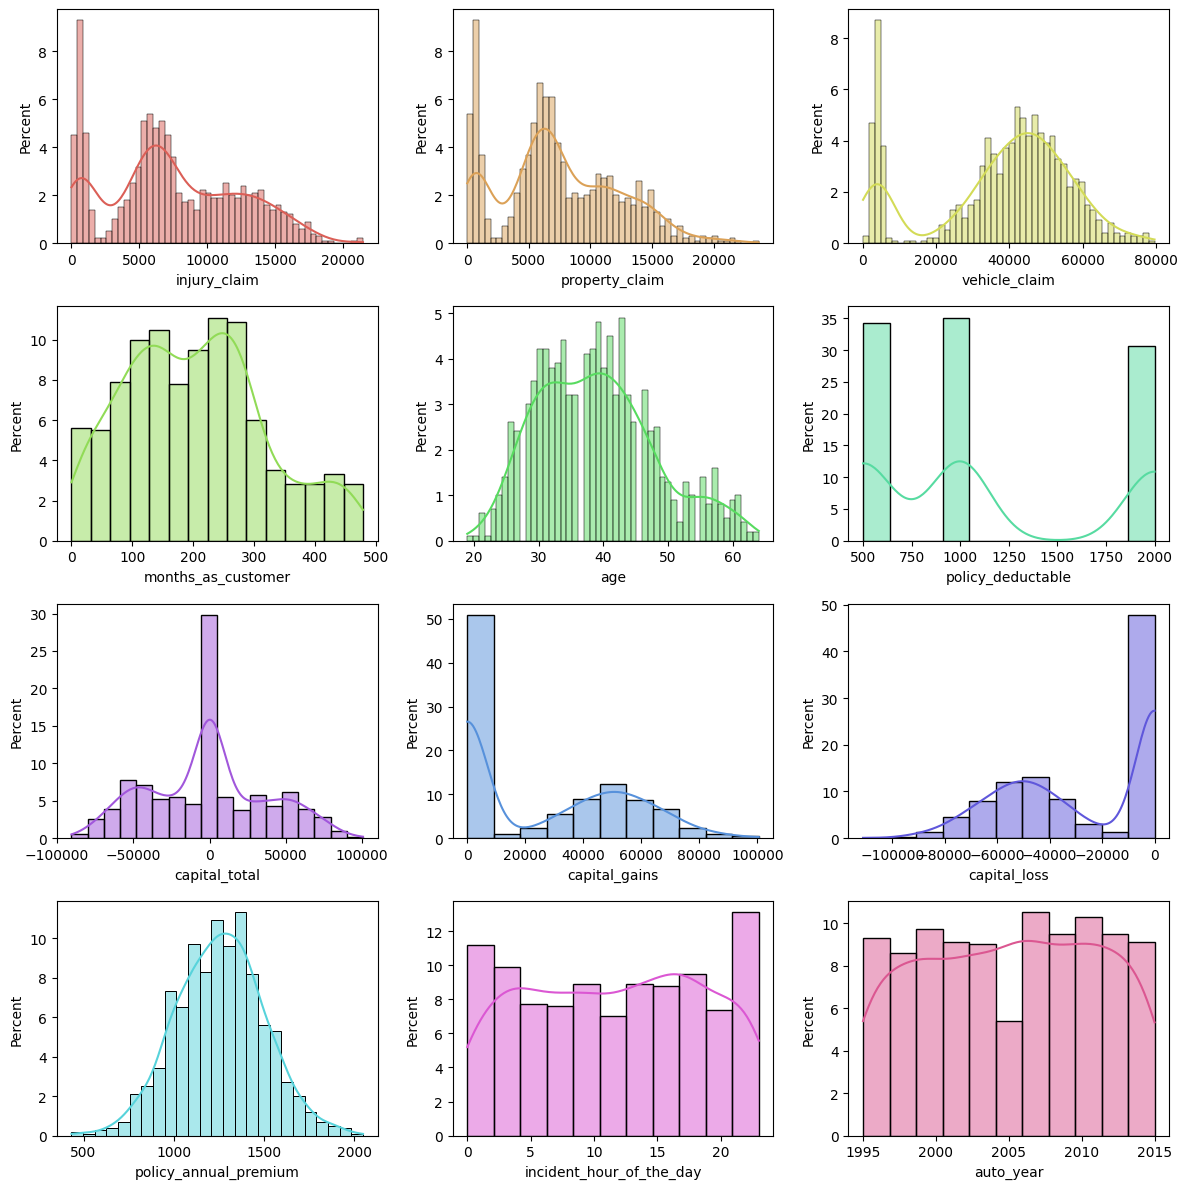

In [203]:
palette = sns.color_palette("hls", 12)
fig, axes = plt.subplots(4, 3, figsize=(12, 12))
sns.histplot(x=df['injury_claim'], ax=axes[0, 0], bins=50, kde=True, color=palette[0], stat="percent")
sns.histplot(x=df['property_claim'], ax=axes[0, 1], bins=50, kde=True, color=palette[1], stat="percent")
sns.histplot(x=df['vehicle_claim'], ax=axes[0, 2], bins=50, kde=True, color=palette[2], stat="percent")
sns.histplot(x=df['months_as_customer'], ax=axes[1, 0], kde=True, color=palette[3], stat="percent")
sns.histplot(x=df['age'], ax=axes[1, 1], bins=50, kde=True, color=palette[4], stat="percent")
sns.histplot(x=df['policy_deductable'], ax=axes[1, 2], kde=True, color=palette[5], stat="percent")
sns.histplot(x=df['policy_annual_premium'], ax=axes[3, 0], kde=True, color=palette[6], stat="percent")
sns.histplot(x=df['capital_gains'], ax=axes[2, 1], kde=True, color=palette[7], stat="percent")
sns.histplot(x=df['capital_loss'], ax=axes[2, 2], kde=True, color=palette[8], stat="percent")
sns.histplot(x=df['capital_total'], ax=axes[2, 0], kde=True, color=palette[9], stat="percent")
sns.histplot(x=df['incident_hour_of_the_day'], ax=axes[3, 1], kde=True, color=palette[10], stat="percent")
sns.histplot(x=df['auto_year'], ax=axes[3, 2], kde=True, color=palette[11], stat="percent")

plt.tight_layout()
plt.show()

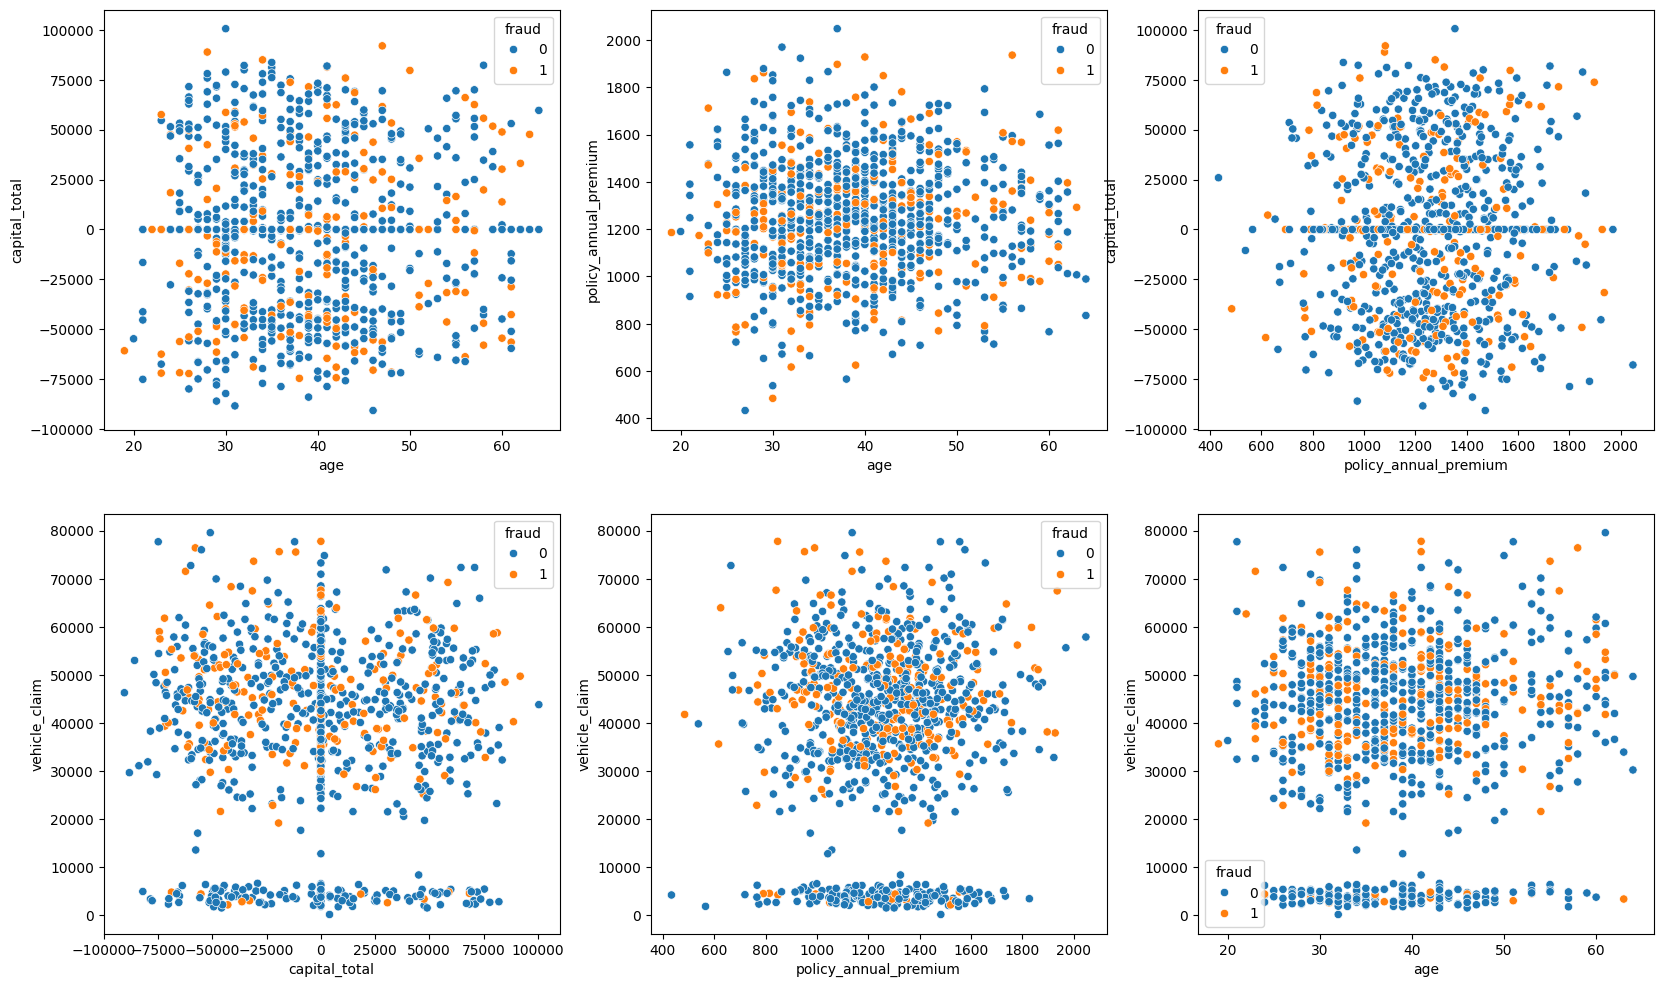

In [213]:

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
sns.scatterplot(x='age',y='capital_total', data=df, hue='fraud', ax=axes[0,0])
sns.scatterplot(x='age',y='policy_annual_premium', data=df, hue='fraud', ax=axes[0,1])
sns.scatterplot(x='age',y='vehicle_claim', data=df, hue='fraud' ,ax=axes[1,2])
sns.scatterplot(x='capital_total',y='vehicle_claim', data=df, hue='fraud' ,ax=axes[1,0])
sns.scatterplot(x='policy_annual_premium',y='vehicle_claim', data=df, hue='fraud' ,ax=axes[1,1])
sns.scatterplot(x='policy_annual_premium',y='capital_total', data=df, hue='fraud' ,ax=axes[0,2]);

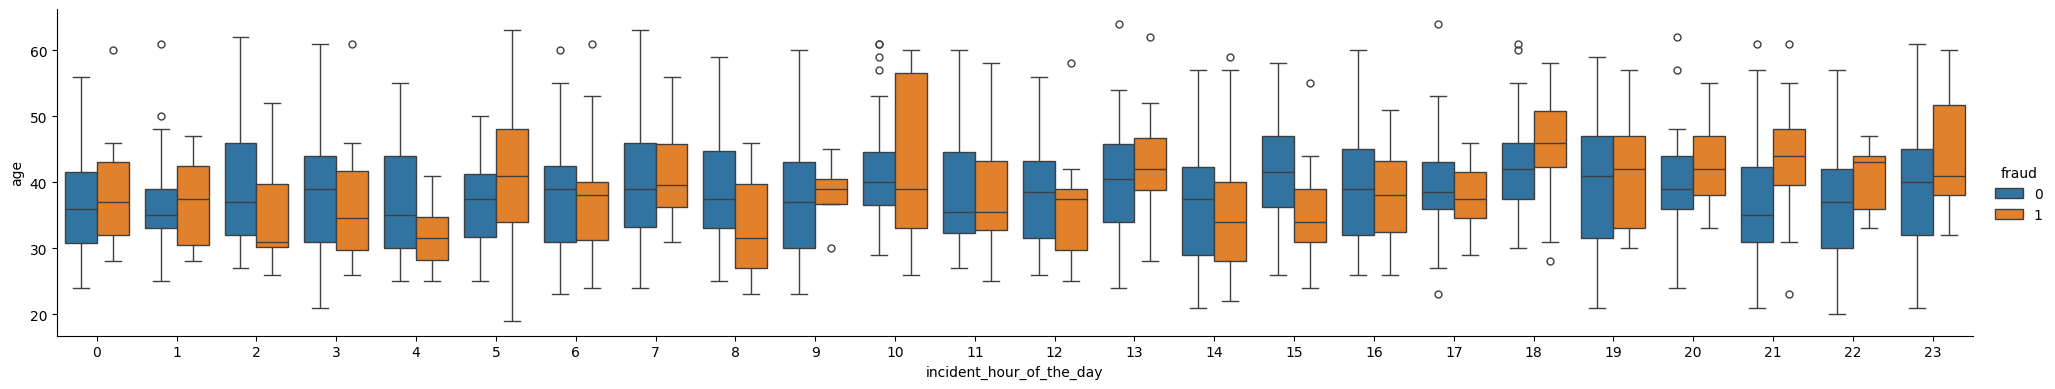

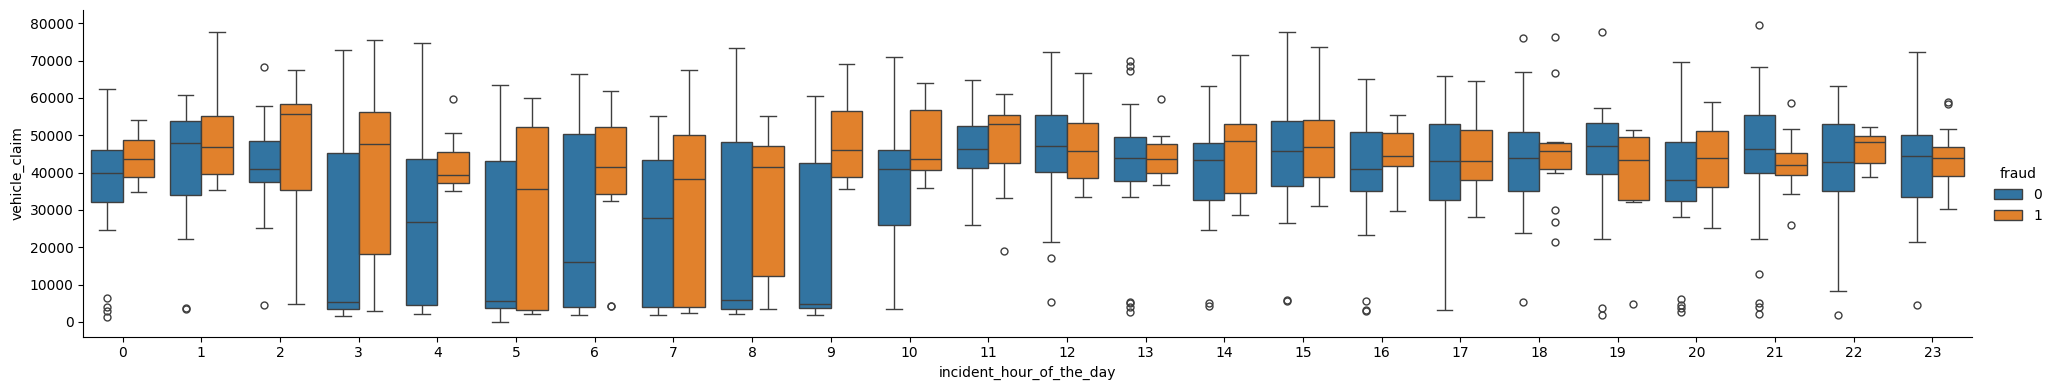

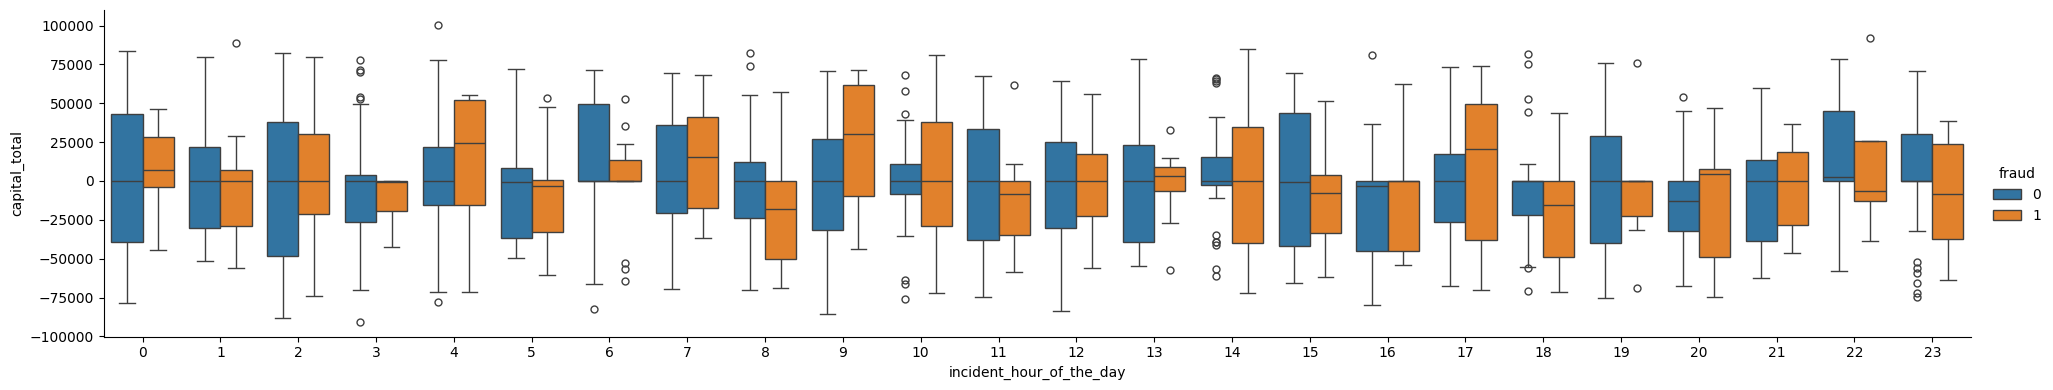

In [205]:

sns.catplot(x='incident_hour_of_the_day',y='age', data=df,hue='fraud',kind='box',height=4, aspect=5)
sns.catplot(x='incident_hour_of_the_day',y='vehicle_claim', data=df, hue='fraud', kind='box',height=4, aspect=5)
sns.catplot(x='incident_hour_of_the_day',y='capital_total', data=df, hue='fraud',kind='box',height=4, aspect=5);

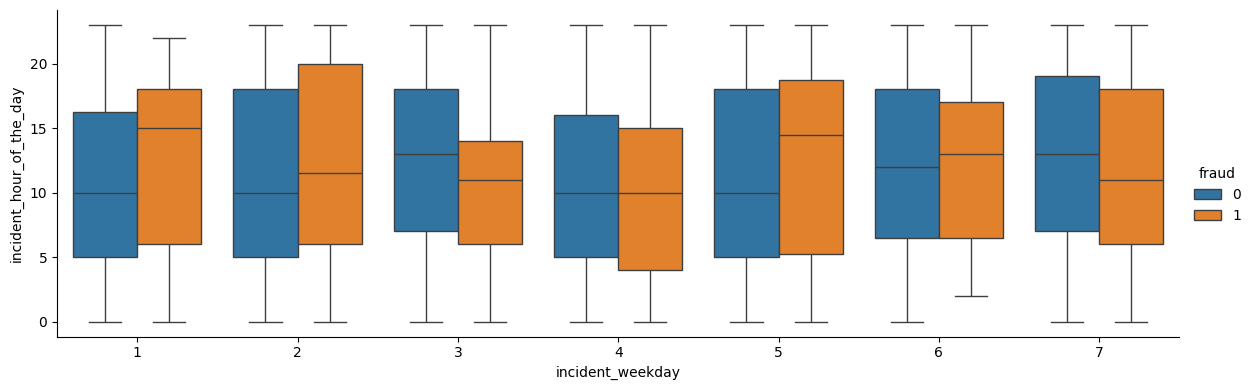

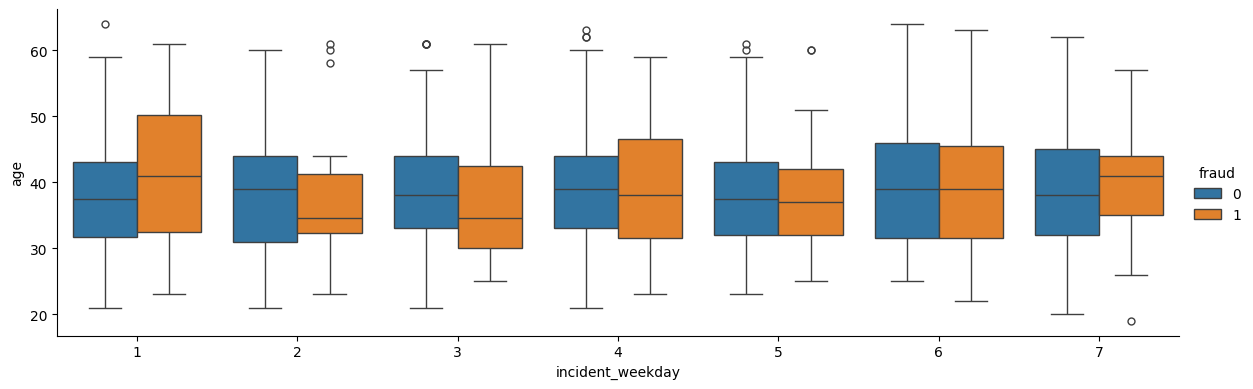

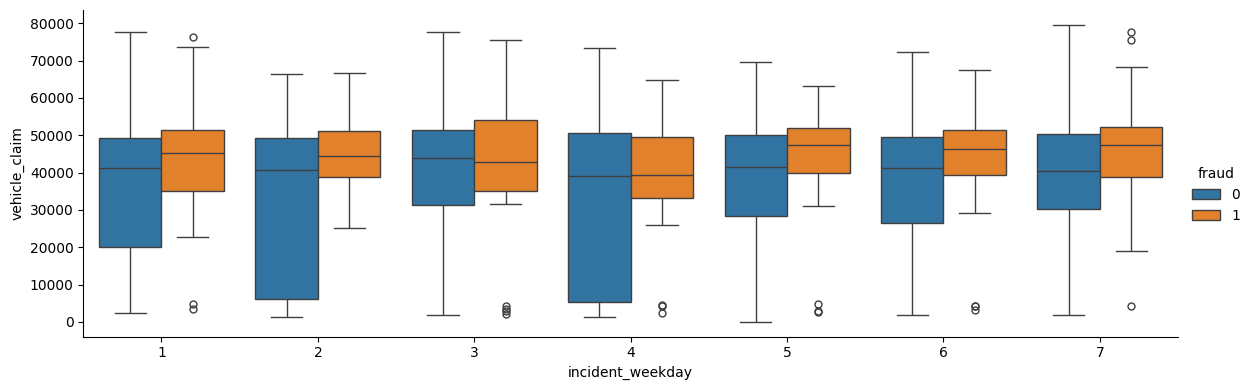

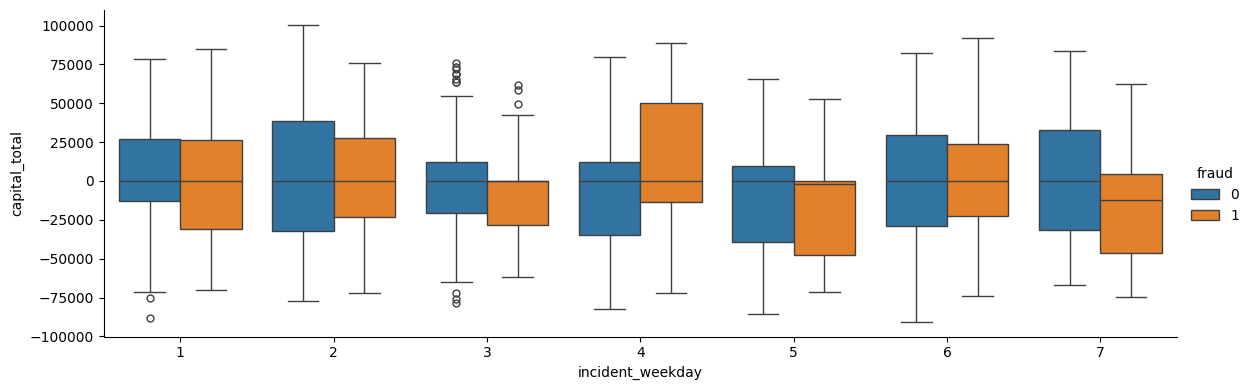

In [206]:
sns.catplot(y='incident_hour_of_the_day',x='incident_weekday', data=df, hue='fraud',kind='box',height=4, aspect=3)
sns.catplot(x='incident_weekday',y='age', data=df,hue='fraud',kind='box',height=4, aspect=3)
sns.catplot(x='incident_weekday',y='vehicle_claim', data=df, hue='fraud', kind='box',height=4, aspect=3)
sns.catplot(x='incident_weekday',y='capital_total', data=df, hue='fraud',kind='box',height=4, aspect=3);

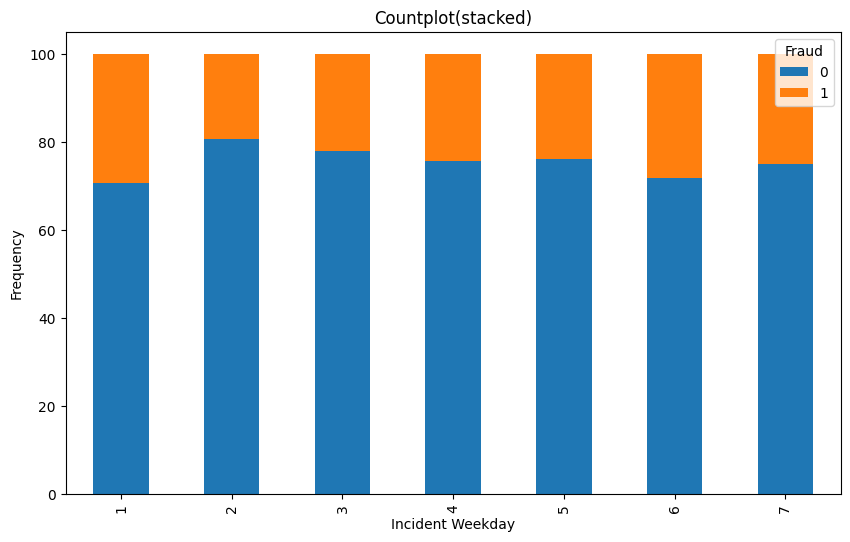

In [ ]:

data = df.groupby(['incident_weekday', 'fraud']).size().unstack().fillna(0)

data_percent = data.divide(data.sum(axis=1), axis=0) * 100

data_percent.plot(kind='bar', stacked=True, figsize=(10,6))
plt.xlabel('Incident Weekday')
plt.ylabel('Frequency')
plt.title('Countplot(stacked)')
plt.legend(title='Fraud')
plt.show()

In [208]:
from scipy.stats import ttest_ind

group0 = df[df['fraud'] == 0]['age']
group1 = df[df['fraud'] == 1]['age']

t_stat, p_value = ttest_ind(group0, group1)

print('Result on feature: Age')
print("t-Statistik:", t_stat)
print("p-Wert:", p_value)

print('Result on feature: Policy_annual_premium')
group0 = df[df['fraud'] == 0]['policy_annual_premium']
group1 = df[df['fraud'] == 1]['policy_annual_premium']

t_stat, p_value = ttest_ind(group0, group1)

print("t-Statistik:", t_stat)
print("p-Wert:", p_value)

print('Result on feature: capital_total')
group0 = df[df['fraud'] == 0]['capital_total']
group1 = df[df['fraud'] == 1]['capital_total']

t_stat, p_value = ttest_ind(group0, group1)

print("t-Statistik:", t_stat)
print("p-Wert:", p_value)

Result on feature: Age
t-Statistik: -0.38365092414841734
p-Wert: 0.7013189051151347
Result on feature: Policy_annual_premium
t-Statistik: 0.4574753742411815
p-Wert: 0.6474289700892819
Result on feature: capital_total
t-Statistik: 0.7786053001898863
p-Wert: 0.43639681850510637


In [210]:
df.drop(["total_claim_amount",'policy_deductable'], axis=1, inplace=True)